In [19]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, classification_report
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [4]:
%run "../04_dataset_transforms/dataset.ipynb"

Train: 3094
Validation: 774
{'ambulance': 0, 'autobus': 1, 'kamyun': 2, 'minibus': 3, 'savari': 4, 'taxi': 5, 'vanet': 6}
Train dataset size: 3094
Validation dataset size: 774
Image type: <class 'PIL.Image.Image'>
Label: 0
Image size: (207, 276)
Label type: <class 'int'>
Original size: (207, 276)
Resized size: (224, 224)
Type: <class 'torch.Tensor'>
Shape: torch.Size([3, 224, 224])
Min: tensor(0.0118)
Max: tensor(1.)
Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Label: 0
Label type: <class 'int'>


# 11.1 — Transform , Dataset

In [5]:
train_dataset = TrafficVehicleDataset(
    train_df,
    class_to_idx,
    transform=train_transform
)
val_dataset = TrafficVehicleDataset(
    val_df,
    class_to_idx,
    transform=val_transform
)

In [6]:
batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [7]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


# 11.2 — CNN + Dropout

In [8]:
class DropoutCNN(nn.Module):
    def __init__(self, num_classes, dropout_p=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout_p),
            nn.Linear(64 * 56 * 56, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 11.3 — model, loss, optimizer, decive

In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print('Device:',device)
print('='*80)

model_dropout = DropoutCNN(num_classes=7, dropout_p=0.5).to(device)
print(model_dropout)
print('='*80)

print("Model device:", next(model_dropout.parameters()).device) 
print('='*80)

criterion = nn.CrossEntropyLoss()
print("Loss:", criterion)
print('='*80)

optimizer = torch.optim.Adam(
    model_dropout.parameters(),
    lr=0.001
)
print("Optimizer:\n", optimizer)

Device: cpu
DropoutCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=200704, out_features=7, bias=True)
  )
)
Model device: cpu
Loss: CrossEntropyLoss()
Optimizer:
 Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# 11.4 — Training loop 

In [10]:
num_epochs = 10
best_val_accuracy = 0.0
best_epoch = 0

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    # Training
    model_dropout.train()
    running_train_loss = 0.0
    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_dropout(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    # Validation
    model_dropout.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_dropout(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = correct / total

    # save results
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(
            model_dropout.state_dict(),
            "best_dropout_model.pth"
        )
        print("  --> Best dropout model saved!")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

print()
print("\nBest Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_accuracy)

  --> Best dropout model saved!
Epoch [1/10] Train Loss: 1.7582 Val Loss: 0.8438 Val Accuracy: 0.7067
  --> Best dropout model saved!
Epoch [2/10] Train Loss: 0.6521 Val Loss: 0.5738 Val Accuracy: 0.8062
Epoch [3/10] Train Loss: 0.3589 Val Loss: 0.5825 Val Accuracy: 0.7946
  --> Best dropout model saved!
Epoch [4/10] Train Loss: 0.2519 Val Loss: 0.5509 Val Accuracy: 0.8165
  --> Best dropout model saved!
Epoch [5/10] Train Loss: 0.1449 Val Loss: 0.5369 Val Accuracy: 0.8333
Epoch [6/10] Train Loss: 0.0964 Val Loss: 0.6202 Val Accuracy: 0.8230
  --> Best dropout model saved!
Epoch [7/10] Train Loss: 0.0569 Val Loss: 0.6120 Val Accuracy: 0.8372
Epoch [8/10] Train Loss: 0.0619 Val Loss: 0.7545 Val Accuracy: 0.8243
Epoch [9/10] Train Loss: 0.0419 Val Loss: 0.8435 Val Accuracy: 0.8217
Epoch [10/10] Train Loss: 0.0458 Val Loss: 0.9633 Val Accuracy: 0.8204


Best Epoch: 7
Best Validation Accuracy: 0.8372093023255814


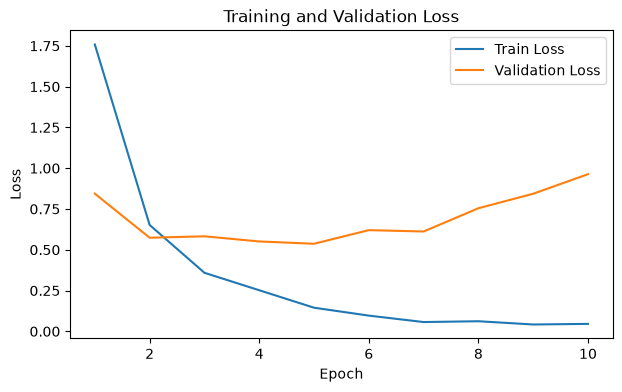

In [14]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7, 4))

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

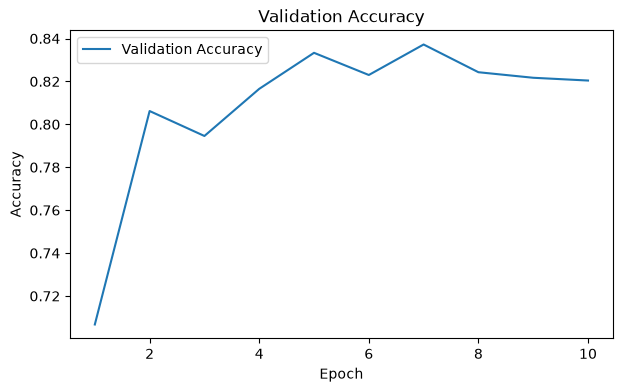

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")

plt.legend()
plt.show()

# 11.5 — Baseline evaluation on the validation set

In [11]:
model_dropout.load_state_dict(
    torch.load(
        'best_dropout_model.pth',
        map_location=device
    )
)
model_dropout = model_dropout.to(device)
model_dropout.eval()
print("Best Dropout Model Loaded")

Best Dropout Model Loaded


In [12]:
all_predictions_dropout = []
all_labels_dropout  = []
model_dropout.eval()
with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_dropout(images)
        predictions = outputs.argmax(dim=1)

        all_predictions_dropout.extend(predictions.cpu().numpy())
        all_labels_dropout.extend(labels.cpu().numpy())

print("Predictions:", len(all_predictions_dropout))
print("Labels:", len(all_labels_dropout))

Predictions: 774
Labels: 774


# 11.6 — Precision , Recall , F1 , confusion_matrix

In [13]:
accuracy = accuracy_score(all_labels_dropout, all_predictions_dropout)
precision = precision_score(all_labels_dropout, all_predictions_dropout, average="macro")
recall = recall_score(all_labels_dropout, all_predictions_dropout, average="macro")
f1 = f1_score(all_labels_dropout, all_predictions_dropout, average="macro")
cm = confusion_matrix(all_labels_dropout, all_predictions_dropout)

print("Validation Accuracy :", accuracy)
print("Validation Precision:", precision)
print("Validation Recall   :", recall)
print("Validation F1 Score :", f1)
print('confusion_matrix    :\n',cm)

Validation Accuracy : 0.8372093023255814
Validation Precision: 0.8405034344254941
Validation Recall   : 0.8336448231355599
Validation F1 Score : 0.8359538865809419
confusion_matrix    :
 [[ 59   0   6   3   2   0   2]
 [  1  73  12   2   2   2   1]
 [ 13   6 157   7   0   1   5]
 [  1   0  15  62   0   0   0]
 [  2   2   0   0  85   0  11]
 [  2   1   2   0   5  86   1]
 [  2   0   4   1  11   1 126]]


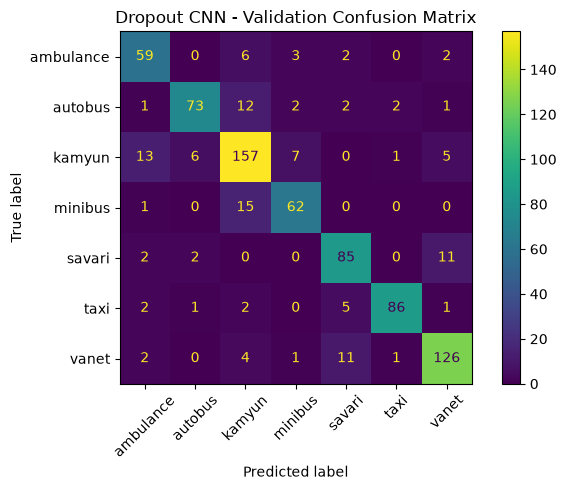

In [20]:
classes = [
    'ambulance',
    'autobus',
    'kamyun',
    'minibus',
    'savari',
    'taxi',
    'vanet'
]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(
    ax=ax,
    xticks_rotation=45
)
plt.title("Dropout CNN - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

# classification_report

In [17]:
report = classification_report(all_labels_dropout, all_predictions_dropout, target_names=classes)
print(report)

              precision    recall  f1-score   support

   ambulance       0.74      0.82      0.78        72
     autobus       0.89      0.78      0.83        93
      kamyun       0.80      0.83      0.82       189
     minibus       0.83      0.79      0.81        78
      savari       0.81      0.85      0.83       100
        taxi       0.96      0.89      0.92        97
       vanet       0.86      0.87      0.87       145

    accuracy                           0.84       774
   macro avg       0.84      0.83      0.84       774
weighted avg       0.84      0.84      0.84       774

